# Online Shoppers Purchasing Intention — Assignment 2

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

import os
os.makedirs("model", exist_ok=True)

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = "online_shoppers_intention.csv"

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv
(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.info()
print()
print(df['Revenue'].value_counts())
print()
print("Missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
TARGET = "Revenue"
df[TARGET] = df[TARGET].astype(int)      # True/False -> 1/0
df["Weekend"] = df["Weekend"].astype(int)

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Save the held-out test split (features + true label) for the Streamlit app
test_export = X_test.copy()
test_export[TARGET] = y_test.values
test_export.to_csv("test_data.csv", index=False)
print("Saved test_data.csv with", len(test_export), "rows")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
Categorical features: ['Month', 'VisitorType']
Saved test_data.csv with 2466 rows


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=RANDOM_STATE
    ),
}

In [ ]:
results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    results.append(metrics)
    fitted_pipelines[name] = pipe

    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    with open(f"model/{safe_name}.pkl", "wb") as f:
        pickle.dump(pipe, f)

    print(f"\n{name}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k}: {v:.4f}")

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.to_csv("model/metrics_comparison.csv")

schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
}
with open("model/schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("\nAll models trained and saved to model/ folder.")


Logistic Regression
  Accuracy: 0.8812
  AUC: 0.8877
  Precision: 0.7432
  Recall: 0.3560
  F1: 0.4814
  MCC: 0.4603

Decision Tree
  Accuracy: 0.8556
  AUC: 0.7307
  Precision: 0.5330
  Recall: 0.5497
  F1: 0.5412
  MCC: 0.4557

kNN
  Accuracy: 0.8739
  AUC: 0.7993
  Precision: 0.6715
  Recall: 0.3639
  F1: 0.4720
  MCC: 0.4322

Naive Bayes
  Accuracy: 0.6736
  AUC: 0.7939
  Precision: 0.2941
  Recall: 0.7906
  F1: 0.4287
  MCC: 0.3249

Random Forest (Ensemble)
  Accuracy: 0.8994
  AUC: 0.9236
  Precision: 0.7410
  Recall: 0.5393
  F1: 0.6242
  MCC: 0.5774

All models trained and saved to model/ folder.


In [ ]:
results_df.style.highlight_max(axis=0, color="#c6f6d5")

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.881200,0.887700,0.743200,0.356000,0.481400,0.460300
Decision Tree,0.855600,0.730700,0.533000,0.549700,0.541200,0.455700
kNN,0.873900,0.799300,0.671500,0.363900,0.472000,0.432200
Naive Bayes,0.673600,0.793900,0.294100,0.790600,0.428700,0.324900
Random Forest (Ensemble),0.899400,0.923600,0.741000,0.539300,0.624200,0.577400


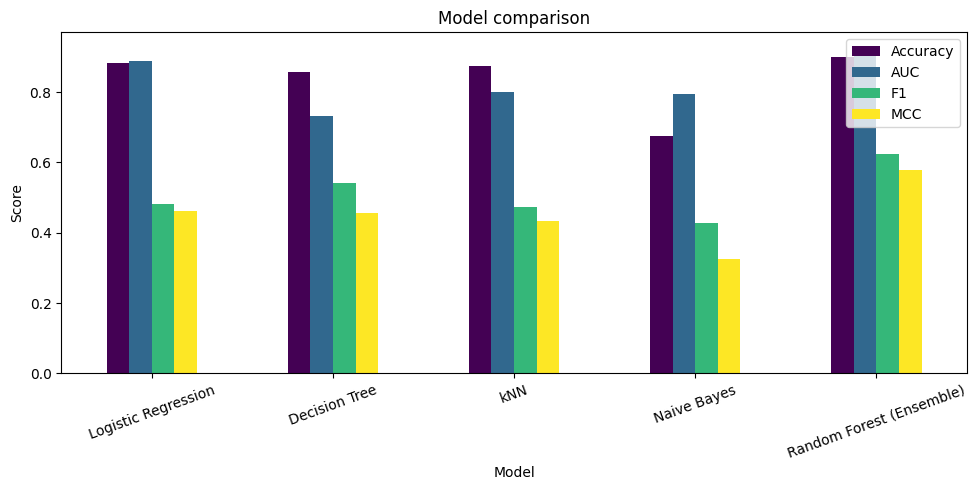

In [ ]:
results_df[["Accuracy", "AUC", "F1", "MCC"]].plot(
    kind="bar", figsize=(10, 5), rot=20, colormap="viridis"
)
plt.title("Model comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

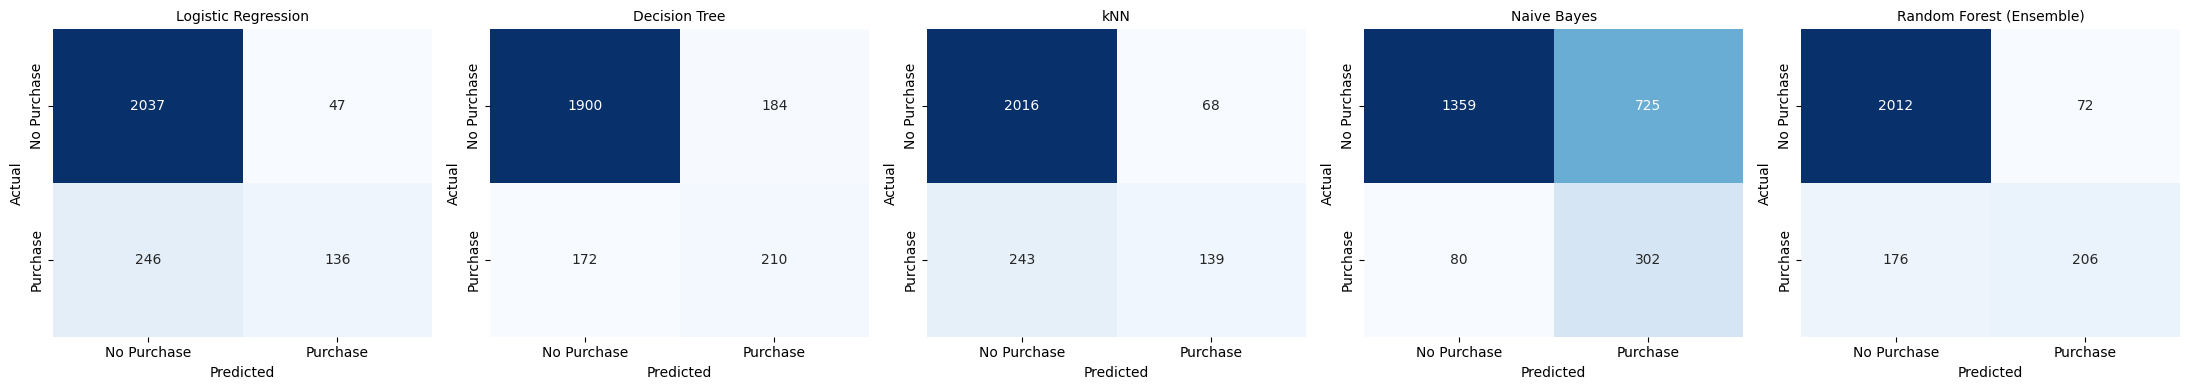

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Purchase", "Purchase"],
                yticklabels=["No Purchase", "Purchase"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
import shutil

shutil.make_archive("assignment2_artifacts", "zip", ".", "model")

try:
    from google.colab import files
    files.download("assignment2_artifacts.zip")
    files.download("test_data.csv")
except ImportError:
    print("Not running in Colab — files are already saved locally in this folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>